#CAPTURE-24 Dataset 기반 일상생활행동(ADL) 분류를 위한 Residual CNN

WillettsSpecific2018 라벨을 기준으로 활동 강도 분류를 수행

In [ ]:
# 라이브러리 import
import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, Activation,
    MaxPooling1D, GlobalAveragePooling1D,
    Dense, Dropout, Add
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef,
    confusion_matrix
)
# 구글 드라이브 연결
drive.mount('/content/drive')

Mounted at /content/drive


## 비중첩 슬라이싱을 사용한 이유
### 중첩 슬라이싱
중첩 슬라이싱은 읜도우가 서로 일부 겹치도록 데이터를 나누는 방식.

-> 기출문제를 반복해서 푸는 것과 같다.

장점:
- 동일한 데이터로 더 많은 샘플을 생성할 수 있음
- 행동 전환 구간이 여러 윈도우에 포함되기 때문에 정보 손실이 최소화

단점:
- 윈도우가 겹치면 같은 데이터가 여러 번 나눠지게 되고 이 과정에서 train과 test에 동일한 데이터가 함께 들어갈 수 있다. 그 결과 모델이 이미 본 데이터를 다시 예측하게 되어 진짜 성능을 제대로 평가 할 수 없다.

### 비중첩 슬라이싱
비중첩 슬라이싱은 윈도우 간 데이터가 겹치지 않도록 분할하는 방식.

->처음 보는 문제를 푸는 것과 같다.

장점:
- 샘플 간 중복이 없어 데이터의 독립성이 확보
- 정확한 성능을 평가 가능(일반화 성능 증가)

단점:
- 중첩이 없어 학습 데이터가 감소
- 슬라이싱과 슬라이싱 사이 경계에서 행동 일부가 잘려 정보 손실 가능성

### 이러한 단점에도 CAPTURE_24 Dataset에서 비중첩 슬라이싱을 사용한 이유
- 해당 대이터 셋은 24시간 동안 수집된 대규모 연속 시계열 데이터이기 때문에 일부 손실이 전체 성능에 미치는 영향이 크지 않음
- 대부분 행동이 일정 시간 이상 지속되므로 하나의 윈도우 내에서도 충분한 특징 정보 포함 가능

따라서 데이터 누수를 방지하고 모델의 실제 성능을 파악하기 위해 비중첩 슬라이싱을 사용했다.

In [ ]:
# 경로 정의
DATASET_PATH = "/content/drive/MyDrive/capture24"
DICT_PATH    = "/content/drive/MyDrive/capture24/annotation-label-dictionary.csv"
# annotation -> label로 매핑하는 딕셔너리 파일

# 행동 기반 10클래스 분류
#    (sleep, sedentary-screen, sedentary-non-screen, walking,
#     vehicle, bicycling, tasks-light, tasks-moderate,
#     sports-continuous, sport-interrupted)
LABEL_MAP = "label:WillettsSpecific2018"

SENSOR_COLS  = ["x", "y", "z"] # 3축 가속도 (입력 feature)
WINDOW_SIZE  = 1000    # 10초 x 100Hz
STEP_SIZE    = WINDOW_SIZE    # 비중첩 슬라이싱
N_FILES      = 10 # 사용할 파일 개수
BATCH_SIZE   = 64 # 10초짜리 윈도우 64개를 한 번에 학습(gradient 계산 단위)
EPOCHS       = 100 # 학습 반복 횟수

In [ ]:
dic = pd.read_csv(DICT_PATH)
# annotation과 label 간 매핑이 정의된 CSV 로드
dic.columns = [c.strip() for c in dic.columns]
# 컬럼명 공백 제거

ann_col = dic.columns[0]
# 원본 annotation 컬럼
label_dict = dic.set_index(ann_col)[LABEL_MAP].to_dict()
# annotation -> 선택한 label(label:WillettsSpecific2018)로 변환하는 딕셔너리 생성

print(f"라벨 매핑 로드 완료: {len(label_dict)}개 annotation → {LABEL_MAP}")
print(f"클래스: {sorted(set(label_dict.values()))}")

라벨 매핑 로드 완료: 206개 annotation → label:WillettsSpecific2018
클래스: ['bicycling', 'household-chores', 'manual-work', 'mixed-activity', 'sitting', 'sleep', 'sports', 'standing', 'vehicle', 'walking']


#시드 고정 이유
시드란?

랜덤 선택 결과를 동일하게 만들기 위한 기준값

-> 음악 리스트를 항상 같은 순서로 재생하는 것과 같음

이유:
- 전체 데이터 중 일부를 랜덤하게 선택할 때 매 실행마다 동일한 데이터가 선택되도록 하기 위함
- 동일한 데이터로 학습을 수행하여 모델 간 성능을 공정하게 비교하기 위함
- 실험을 반복했을 때 동일한 결과를 얻을 수 있도록 재현성을 확보하기 위함
- 코드 일부를 수정했을 때 데이터 변화가 아닌 코드 변경에 따른 성능만을 확하기 위함

In [ ]:
# 전체 데이터 중 일부를 랜덤하게 선택하지만 항상 동일하게 선택되도록 고정
# 시드를 고정하면 동일한 데이터로 학습하게 되어 모델 간 성능을 공정하게 비교 가능
all_files = [
    fp for fp in glob.glob(os.path.join(DATASET_PATH, "*.csv.gz"))
]
# 데이터셋 폴더에서 모든 센서 csv.gz 파일 경로 수집

np.random.seed(42)
# 랜덤 시드 고정 (같은 파일 샘플링을 위해, 재현성 보장)
files = np.random.choice(
    all_files,
    size=min(N_FILES, len(all_files)),
    replace=False
)
# 전체 파일 중 N_FILES개를 중복 없이 랜덤 선택

print(f"\n{len(files)}개 파일 사용:")
print([os.path.basename(f) for f in files])


10개 파일 사용:
['P151.csv.gz', 'P097.csv.gz', 'P138.csv.gz', 'P076.csv.gz', 'P054.csv.gz', 'P078.csv.gz', 'P052.csv.gz', 'P075.csv.gz', 'P121.csv.gz', 'P112.csv.gz']


In [ ]:
sample_df = pd.read_csv(files[0], nrows=2)
# 첫 번째 파일 일부만 읽어 컬럼명 확인

col_map = {c.lower(): c for c in sample_df.columns}
# 대소문자 차이로 인한 컬럼명 오류 방지

SENSOR_COLS = [col_map[c] for c in ["x", "y", "z"]]
# 실제 데이터에서 x, y, z 센서 컬럼명 자동 감지

ANN_COL = col_map.get("annotation", "annotation")
# annotation 컬럼명 자동 감지

print(f"\n감지된 센서 열: {SENSOR_COLS}")
print(f"감지된 라벨 열: {ANN_COL}")

all_X = []
all_y = []
# 생성된 윈도우 데이터와 라벨을 리스트에 저장

for fp in files:
    print(f"로드 중: {os.path.basename(fp)}")

    df = pd.read_csv(fp)
    # 센서 CSV 파일 로드
    df = df.dropna(subset=SENSOR_COLS + [ANN_COL])
    # 센서값 또는 annotation이 없는 행 제거


    df["label"] = df[ANN_COL].map(label_dict)
    # annotation -> Walmsley2020 label 매핑

    df = df.dropna(subset=["label"])
    # 라벨 매핑이 되지 않은 행 제거

    data = df[SENSOR_COLS].values.astype(np.float32)
    # x, y, z 센서값을 모델 입력 형태로 변환
    labels = df["label"].values
    # 각 시점의 라벨 배열 생성

    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        # WINDOW_SIZE 길이만큼 데이터를 자르고 STEP_SIZE만큼 이동
        end = start + WINDOW_SIZE

        window_x = data[start:end]
        # 하나의 시계열 윈도우 생성
        window_labels = labels[start:end]
        # 해당 윈도우 구간의 라벨 추출

        window_y = pd.Series(window_labels).mode()[0]
        # 윈도우 내부에서 가장 많이 등장한 라벨을 대표 라벨로 사용

        all_X.append(window_x)
        all_y.append(window_y)
        # 생성된 윈도우와 라벨 저장

X = np.array(all_X)
y_raw = np.array(all_y)
# 리스트를 NumPy 배열로 변환

print(f"\nX shape: {X.shape}")
print(f"y shape: {y_raw.shape}")


감지된 센서 열: ['x', 'y', 'z']
감지된 라벨 열: annotation
로드 중: P151.csv.gz


/tmp/ipykernel_2628/2010532964.py:23: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fp)


로드 중: P097.csv.gz


/tmp/ipykernel_2628/2010532964.py:23: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fp)


로드 중: P138.csv.gz


...

로드 중: P121.csv.gz


/tmp/ipykernel_2628/2010532964.py:23: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fp)


로드 중: P112.csv.gz


/tmp/ipykernel_2628/2010532964.py:23: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fp)



X shape: (63089, 1000, 3)
y shape: (63089,)


In [ ]:
le = LabelEncoder()
# 문자열 형태의 클래스 라벨을 숫자로 변환하기 위한 인코더 생성
y = le.fit_transform(y_raw)
# 각 라벨을 0 ~ (클래스 수 - 1) 범위의 정수로 변환

NUM_CLASSES = len(le.classes_)
# 전체 클래스 개수 계산
LABELS = list(le.classes_)
# 클래스 이름 목록 저장

print(f"\n클래스 수: {NUM_CLASSES}")
print(f"클래스 목록: {LABELS}")


클래스 수: 10
클래스 목록: [np.str_('bicycling'), np.str_('household-chores'), np.str_('manual-work'), np.str_('mixed-activity'), np.str_('sitting'), np.str_('sleep'), np.str_('sports'), np.str_('standing'), np.str_('vehicle'), np.str_('walking')]


In [ ]:
# Train / Test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y # train/test 분할 시 클래스 비율을 동일하게 유지하여 데이터의 난이도를 비슷하게 맞춤
)

#데이터 정규화
데이터 값들의 크기를 비슷하게 맞춰 주는 것.

-> 서로 다른 단위를 가진 키, 몸무게를 같은 기준으로 환산하여 비교하기 쉽게 바꾸는 것과 같다.

-> 정규화를 안할 경우 모델이 큰값에만 집중하여 학습이 제대로 되지 않음.

정규화 과정의 두 단계:
- 1. 평균을 뺀다.
- 2. 표준편차로 나눈다.

## 평균을 빼는 이유
-> 데이터를 0 기준으로 맞추기 위해.
- 데이터마다 기준이 다르면 비교하기 어렵다.
- 평균을 빼면 평균보다 큰지 작은지만 남게 됨.

### 평균 0이 좋은 이유는?

평균이 0이면 데이터가 한쪽으로 치우치지 않아 모델이 0을 기준으로 양쪽 방향의 정보를 모두 활용할 수 있음

-> 그 결과 더 빠르고 안정적으로 학습할 수 있음
## 표준편차로 나누는 이유
-> 데이터의 크기를 맞추기 위해.
- 어떤 값은 크고 어떤 값은 작으면 모델이 헷갈림.
- 나누면 비슷한 범위로 정리된다.

### 왜 표준편차로 나누는가?
- 모델이 데이터의 전체적인 크기보다 평균에서 얼마나 벗어 났는지를 중요하게 봄
-> 따라서 표준편차로 나누어 데이터의 크기를 맞추고 평균 대비 상대적인 차이만 남김

### 평균은 기준을 맞추고 표준편차는 크기를 맞춘다.

In [ ]:
mean = X_train.mean(axis=(0, 1), keepdims=True)
# train 데이터 전체(모든 시간 + 샘플) 기준 평균 계산
std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8
# 표준편차 계산 (0으로 나누는 것 방지 위해 작은 값 추가)

X_train = (X_train - mean) / std
# 평균 0, 분산 1이 되도록 정규화
X_test = (X_test - mean) / std
# train 기준 통계로 test도 동일하게 정규화

y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_oh = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)
# 정수 라벨을 one-hot 벡터로 변환 (softmax 학습용)

In [ ]:
# Residual Block 정의
def residual_block(x, filters, kernel_size=3):
    shortcut = x

    x = Conv1D(filters, kernel_size, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv1D(filters, kernel_size, padding="same")(x)
    x = BatchNormalization()(x)

    # 채널 수가 다르면 shortcut도 1x1 Conv로 맞춤
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, kernel_size=1, padding="same")(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation("relu")(x)

    return x

In [ ]:
# CNN 모델
inputs = Input(shape=(WINDOW_SIZE, len(SENSOR_COLS)))

# Local pattern 추출
x = Conv1D(64, kernel_size=7, padding="same")(inputs)
x = BatchNormalization()(x)
x = Activation("relu")(x)

# Residual block
x = residual_block(x, filters=64, kernel_size=3)
x = MaxPooling1D(pool_size=2)(x)

x = residual_block(x, filters=128, kernel_size=3)
x = MaxPooling1D(pool_size=2)(x)

x = residual_block(x, filters=256, kernel_size=3)
x = MaxPooling1D(pool_size=2)(x)

# Global Pooling
x = GlobalAveragePooling1D()(x)

# Classifier
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1000, 3)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1000, 64)  │      1,408 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1000, 64)  │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1000, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1000, 64)  │     12,352 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1000, 64)  │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 1000, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1000, 64)  │     12,352 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1000, 64)  │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1000, 64)  │          0 │ batch_normalizat… │
│                     │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 1000, 64)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 500, 64)   │          0 │ activation_2[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 500, 128)  │     24,704 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 128)  │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 500, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 500, 128)  │     49,280 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 500, 128)  │      8,320 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 128)  │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 128)  │        512 │ conv1d_5[0][0]  

 Total params: 476,426 (1.82 MB)

 Trainable params: 473,738 (1.81 MB)

 Non-trainable params: 2,688 (10.50 KB)

In [ ]:
history = model.fit(
    X_train,
    y_train_oh,
    validation_split=0.1,# train 데이터의 10%를 validation으로 사용
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=7,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/100
710/710 ━━━━━━━━━━━━━━━━━━━━ 47s 44ms/step - accuracy: 0.5973 - loss: 1.1405 - val_accuracy: 0.6292 - val_loss: 1.1032
Epoch 2/100
710/710 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.6649 - loss: 0.9680 - val_accuracy: 0.6878 - val_loss: 0.9047
Epoch 3/100
710/710 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.6890 - loss: 0.8998 - val_accuracy: 0.7126 - val_loss: 0.8349
Epoch 4/100
710/710 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.7000 - loss: 0.8704 - val_accuracy: 0.7132 - val_loss: 0.8059
Epoch 5/100
710/710 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.7081 - loss: 0.8455 - val_accuracy: 0.7286 - val_loss: 0.7690
Epoch 6/100
710/710 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.7145 - loss: 0.8271 - val_accuracy: 0.7304 - val_loss: 0.7552
Epoch 7/100
710/710 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.7203 - loss: 0.8071 - val_accuracy: 0.7254 - val_loss: 0.7631
Epoch 8/100
710/710 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.7250 - loss: 0

In [ ]:
# 테스트 평가
y_pred_prob = model.predict(X_test)
# 각 샘플에 대해 클래스별 확률 출력 (softmax 결과)
y_pred = y_pred_prob.argmax(axis=1)
# 가장 확률이 높은 클래스를 최종 예측값으로 선택

acc = (y_test == y_pred).mean()
# 전체 중 맞춘 비율(정확도)
macro_f1 = f1_score(y_test, y_pred, average="macro")
# 클래스별 F1-score를 평균 (모든 클래스를 동일하게 반영)
kappa = cohen_kappa_score(y_test, y_pred)
# 우연히 맞춘 비율을 보정한 정확도
mcc = matthews_corrcoef(y_test, y_pred)
# 클래스 불균형을 고려한 종합 성능 지표

print("\n===== Test Result =====")
print(f"Test Accuracy : {acc:.4f}")
print(f"Macro F1      : {macro_f1:.4f}")
print(f"Cohen's Kappa : {kappa:.4f}")
print(f"MCC           : {mcc:.4f}")

395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step

===== Test Result =====
Test Accuracy : 0.7909
Macro F1      : 0.6415
Cohen's Kappa : 0.7109
MCC           : 0.7127


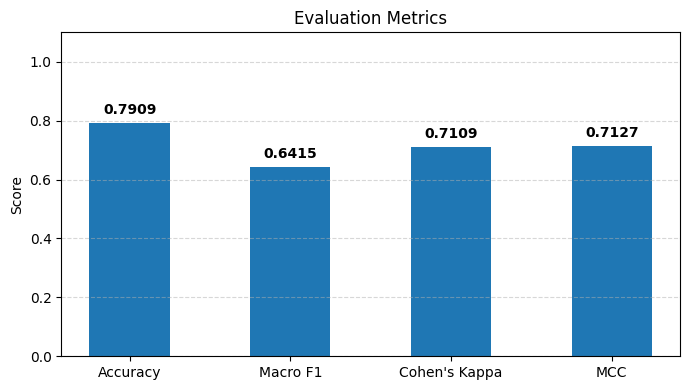

In [ ]:
# 평가 지표 바 차트
metrics = {
    "Accuracy": acc,
    "Macro F1": macro_f1,
    "Cohen's Kappa": kappa,
    "MCC": mcc
}

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    metrics.keys(),
    metrics.values(),
    width=0.5
)

ax.set_ylim(0, 1.1)
ax.set_title("Evaluation Metrics")
ax.set_ylabel("Score")

for bar, val in zip(bars, metrics.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("metrics_bar.png", dpi=150)
plt.show()

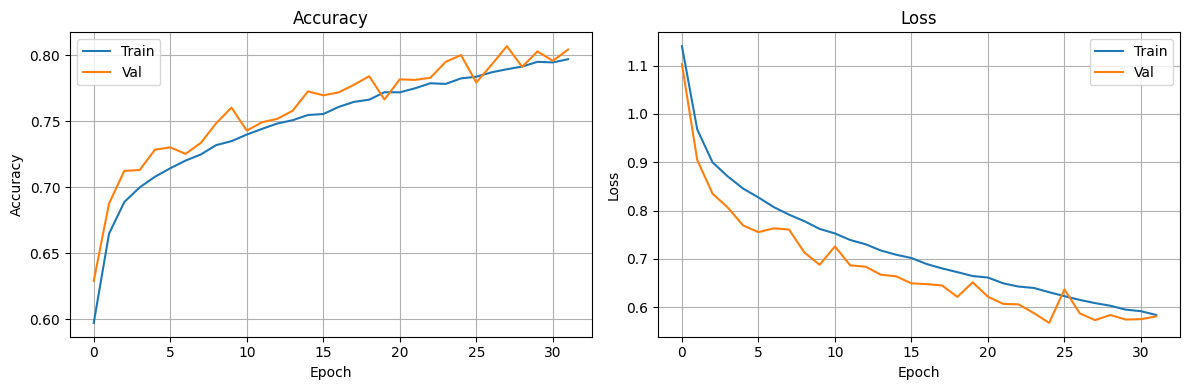

In [ ]:
# 학습 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Val")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Val")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

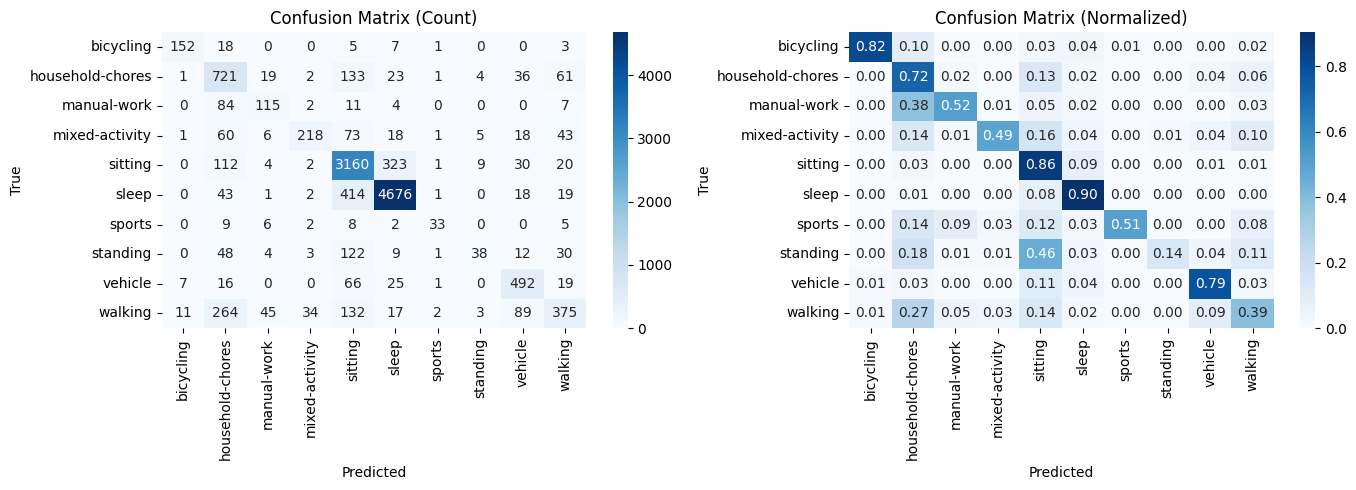

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS,
    ax=axes[0]
)

axes[0].set_title("Confusion Matrix (Count)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS,
    ax=axes[1]
)

axes[1].set_title("Confusion Matrix (Normalized)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()